# Ecowitt — daily report

Yesterday, as a complete local calendar day. Three parts, in the order they
should be read:

1. **Boundary conditions** — is this day's data fit to report on at all
2. **Summary** — the handful of numbers that describe the day
3. **Supporting detail** — the charts and the full table behind those numbers

The order is the point. Every number in parts 2 and 3 is only as good as part 1,
so the checks come first and say plainly whether to trust what follows.

**Scope.** These checks ask *is this day sound* — the window, the grid, the
sensors, the edges of each physical range. Whether the whole record holds up
all-time is `audit.ipynb`'s job, and nothing here duplicates it.

The window is local midnight to local midnight at the native 5-minute
resolution: no aggregation, no partial edges, and 23 or 25 hours on a DST
changeover rather than a wrong 24.

In [1]:
# Preflight: make this notebook work whatever kernel it lands on.
#
# VS Code writes the selected kernel back INTO this file, so pinning a
# kernelspec here loses to whatever was last used. This machine also has
# several Pythons (Anaconda, other project venvs). Rather than fight that,
# fall back to the project venv's site-packages when the current interpreter
# lacks the dependencies -- safe only when the Python versions match exactly,
# because compiled extensions like psycopg are ABI-specific.
import sys
from importlib.util import find_spec
from pathlib import Path

NEEDED = ("psycopg", "sqlalchemy", "pandas", "matplotlib")


def _repo_venv_site_packages():
    """Walk up from the notebook looking for a sibling .venv."""
    for base in (Path.cwd(), *Path.cwd().parents):
        version = f"python{sys.version_info.major}.{sys.version_info.minor}"
        sp = base / ".venv" / "lib" / version / "site-packages"
        if sp.is_dir():
            return sp
    return None


missing = [m for m in NEEDED if find_spec(m) is None]
if missing:
    sp = _repo_venv_site_packages()
    if sp and str(sp) not in sys.path:
        sys.path.insert(0, str(sp))
        missing = [m for m in NEEDED if find_spec(m) is None]
        if not missing:
            print(f"NOTE: running on {sys.executable}")
            print(f"      which lacks {', '.join(NEEDED)}, so this notebook added")
            print(f"      {sp}")
            print("      to sys.path as a fallback. It works because both interpreters are")
            micro = sys.version_info.micro
            print(f"      Python {sys.version_info.major}."
                  f"{sys.version_info.minor}.{micro}.")
            print("      Cleaner: select the 'Python (ecowitt)' kernel (VS Code: kernel name,")
            print("      top-right of the notebook).")

if missing:
    raise SystemExit(
        f"Wrong kernel, and the fallback could not help.\n\n"
        f"  running on : {sys.executable}\n"
        f"  missing    : {', '.join(missing)}\n\n"
        "Select the 'Python (ecowitt)' kernel.\n"
        "  VS Code    : click the kernel name in the notebook's TOP-RIGHT corner\n"
        "               -> Select Another Kernel... -> Jupyter Kernel...\n"
        "  JupyterLab : Kernel > Change Kernel\n\n"
        "If it is not offered, register it once from the repo root:\n"
        "    .venv/bin/python -m ipykernel install --user --name ecowitt \\\n"
        "        --display-name 'Python (ecowitt)'\n\n"
        "If only matplotlib is missing, the venv predates the charting section:\n"
        "    .venv/bin/python -m pip install -e '.[notebook]'"
    )

print(f"kernel OK: {sys.executable}")


kernel OK: /Users/marcalexander/projects/ai_orchestrator_claude/ecowitt_weather/.venv/bin/python3.12


In [2]:
# Shared plumbing lives in notebooks/ecowitt_nb.py -- tunnel, connection,
# palette, fetching, metric metadata, charts. It is imported rather than
# pasted: the same cell copied into two notebooks had to be bug-fixed twice.
import importlib
import pathlib
import sys

import pandas as pd
from sqlalchemy import text

for _base in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (_base / 'notebooks' / 'ecowitt_nb.py').is_file():
        sys.path.insert(0, str(_base / 'notebooks'))
        break
    if (_base / 'ecowitt_nb.py').is_file():
        sys.path.insert(0, str(_base))
        break
else:
    raise SystemExit('cannot find notebooks/ecowitt_nb.py above ' + str(pathlib.Path.cwd()))

import ecowitt_nb as nb  # noqa: E402  -- must follow the sys.path insert above

importlib.reload(nb)          # pick up edits to the module without a kernel restart

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 250)
nb.style()

conn = nb.ensure_db()
print(pd.read_sql(text('select current_user, current_database(), now()'), conn)
        .to_string(index=False))


current_user current_database                              now
  ecowitt_ro          ecowitt 2026-09-21 19:40:45.190136+00:00


In [3]:
import ecowitt_daily as daily

importlib.reload(daily)

conn = nb.ensure_db()

DAY_START, DAY_END = nb.yesterday_bounds()
meta = nb.load_meta(conn)

# 5-minute buckets match the source grid exactly, so each bucket holds a single
# observation and the resample rules are pass-throughs. This is the one view
# where nothing is aggregated at all.
day = nb.fetch_window(conn, DAY_START, DAY_END, bucket='5 minutes', freq='5min')

print(daily.report_title(DAY_START))
print(f'{day.shape[1]} metrics x {len(day)} five-minute slots')

Sunday 20 September 2026 · America/Chicago
39 metrics x 288 five-minute slots


## 1. Boundary conditions

Is this day's data fit to report on? Ten checks, each with a verdict, the
number behind it, and — on hover over the **Measured** cell — why it exists.

**Read across, not just down.** A single day tells you whether today is broken;
the row of days tells you whether something has been drifting. A check that
fails once is an incident, and the same check amber three days running is a
trend that has not been dealt with.

The checks cluster at the boundaries because that is where a day goes wrong:
the edges of the window (did it start and finish landing), of the grid (gaps —
and whether they are scattered or one long hole), and of each sensor's physical
range.

Two exist because a healthy-looking number can hide a broken sensor:
**longest single gap** — one 40-minute hole and eight scattered singles both
read as "97% covered" — and **no flatlined sensor**, since a sensor stuck on one
value scores perfect coverage and only variance catches it.

Whether the whole record holds up all-time is `audit.ipynb`'s job; nothing here
duplicates it.

In [4]:
pivot, measured, notes = daily.rolling_checks(
    conn, meta, nb.fetch_window, DAY_END, days=7)
print(daily.rolling_banner(pivot))
print('hover a Measured cell for why the check exists\n')
display(daily.style_rolling(pivot, measured, notes))

7 of 7 days free of failures · 0 failure(s), 0 warning(s) across the window
hover a Measured cell for why the check exists



,Measured,Mon 14,Tue 15,Wed 16,Thu 17,Fri 18,Sat 19,Sun 20
Check,,,,,,,,
grid coverage,288/288 slots (100.0%),PASS,PASS,PASS,PASS,PASS,PASS,PASS
longest single gap,0 min,PASS,PASS,PASS,PASS,PASS,PASS,PASS
day fully landed,last reading 5 min before midnight,PASS,PASS,PASS,PASS,PASS,PASS,PASS
runs covering the day,succeeded=26,PASS,PASS,PASS,PASS,PASS,PASS,PASS
rows quarantined,0,PASS,PASS,PASS,PASS,PASS,PASS,PASS
values corrected after the fact,0,PASS,PASS,PASS,PASS,PASS,PASS,PASS
no sensor dropped out,none,PASS,PASS,PASS,PASS,PASS,PASS,PASS
values physically possible,all in range,PASS,PASS,PASS,PASS,PASS,PASS,PASS
rain accumulators only reset to zero,none,PASS,PASS,PASS,PASS,PASS,PASS,PASS


## 2. Summary

The day in a dozen numbers — each with **when** it happened, because timing is
half the story. A 104 ºF high at 15:00 is a normal summer afternoon; the same
high at 03:00 is a broken sensor.

Rain is reported as its end-of-day total rather than a mean or a max: it is an
accumulator, so the number that means anything is where it finished.

In [5]:
print(daily.report_title(DAY_START), '\n')
display(daily.headlines(day, meta))

Sunday 20 September 2026 · America/Chicago 



,measure,value,when
0,Outdoor High,102.9 ºF,2:45 PM
1,Outdoor Low,73.0 ºF,7:05 AM
2,Felt Hottest,105.8 ºF,3:55 PM
3,Dew Point High,73.1 ºF,7:05 PM
4,Dew Point Low,58.1 ºF,1:20 AM
5,Humidity High,93 %,7:55 PM
6,Humidity Low,30 %,2:30 PM
7,Peak Gust,7.4 mph,11:25 AM
8,Peak Solar,799 W/m²,1:10 PM
9,Peak UV Index,7,1:05 PM


## 3. Supporting detail

One figure per logical group, panels stacked on a **single shared time axis**.
That shared axis is what makes the day readable as one story: a vertical line
through a figure is one instant, so the cloud that cuts solar irradiance at
13:00 is visibly the same event that cuts UV index at 13:00.

Colour means **location** wherever location is what differs — on "every
thermometer" the lines are outdoor / indoor / ch1 / ch2 / ch3, so the chart
answers *which sensor* directly. Where a panel holds several measures at one
place, colour means the metric instead, and every panel carries its own legend
so the meaning is never assumed.

Gaps are drawn as gaps: each series sits on the full time grid, so a dropout
breaks the line instead of being bridged by one drawn through readings that
were never taken.

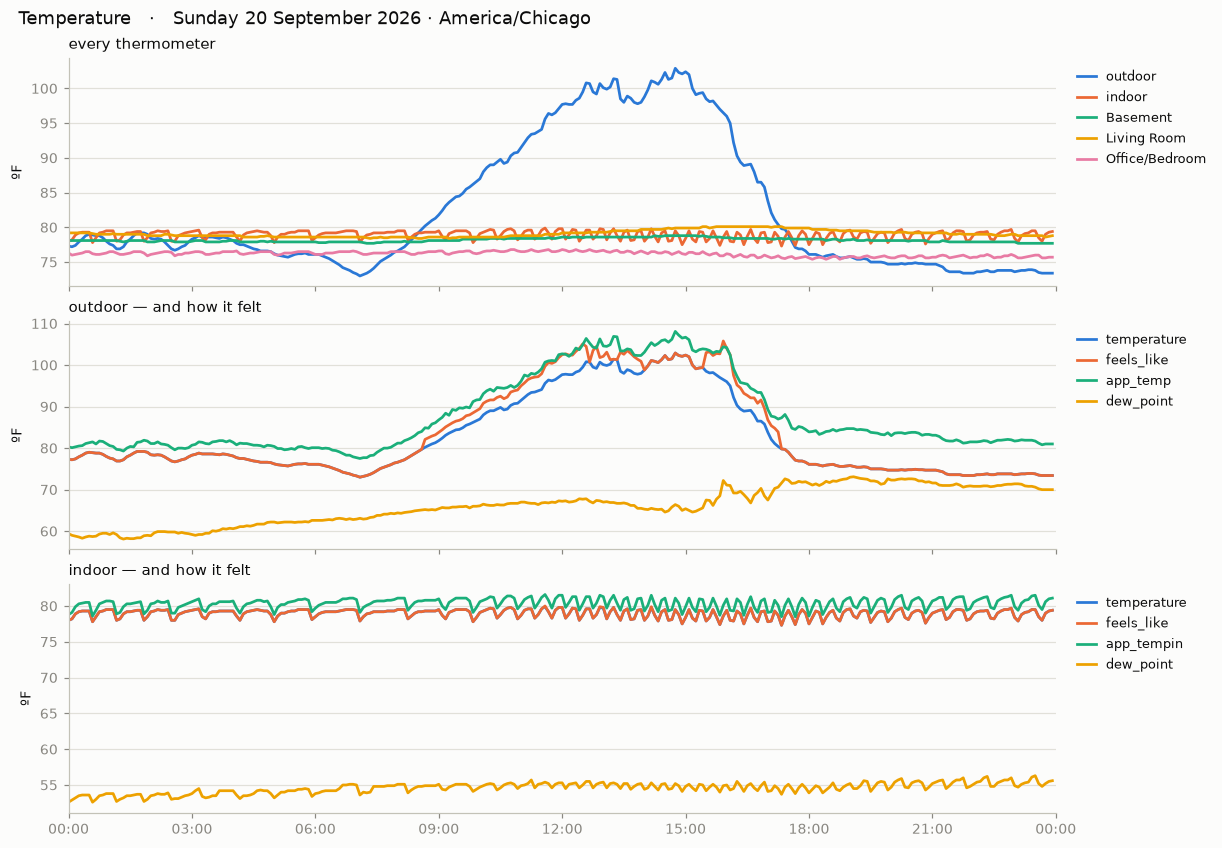

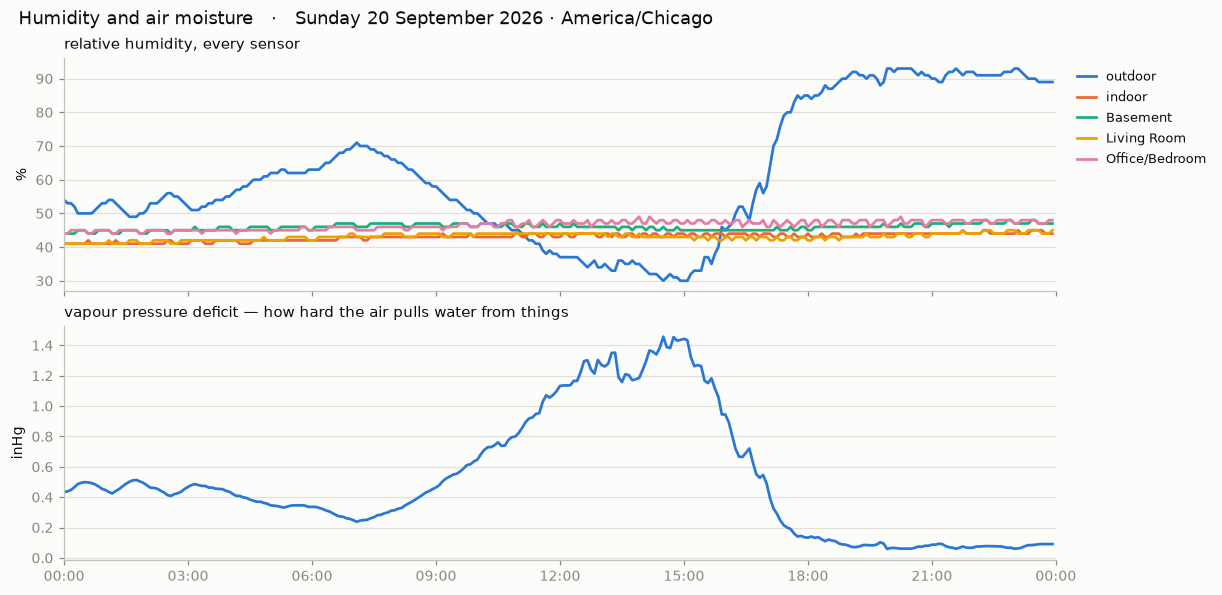

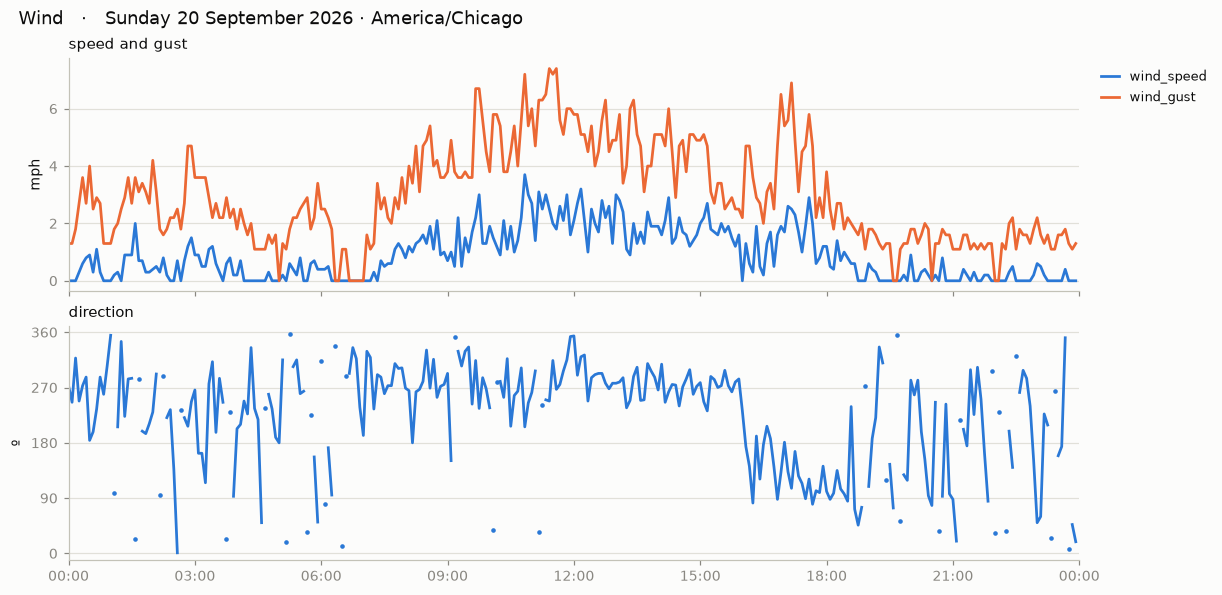

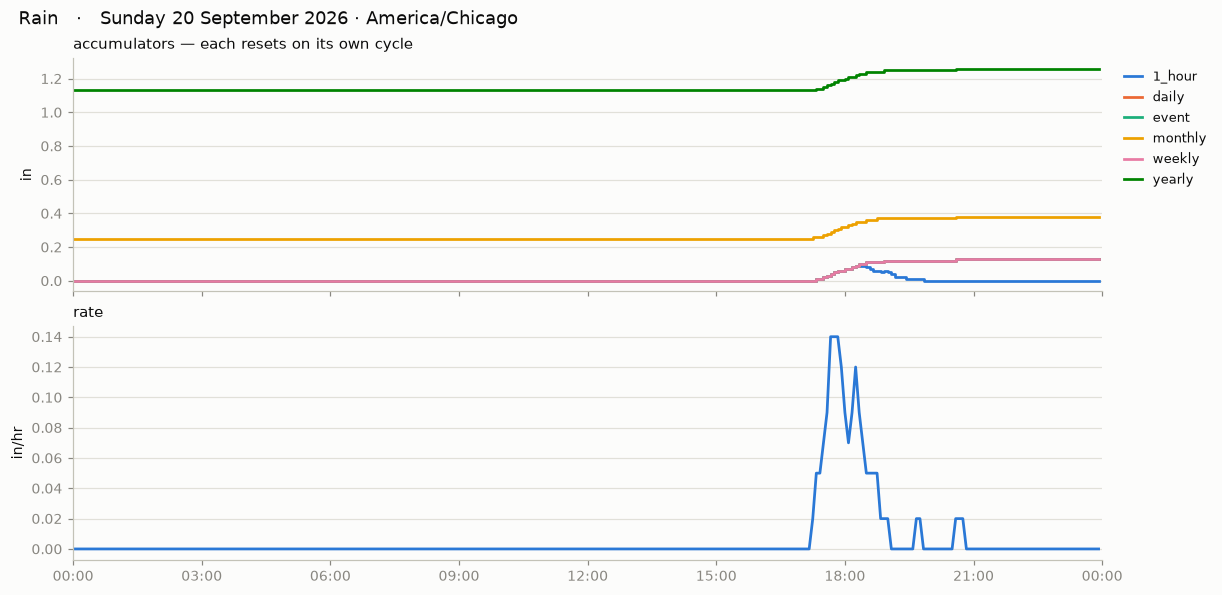

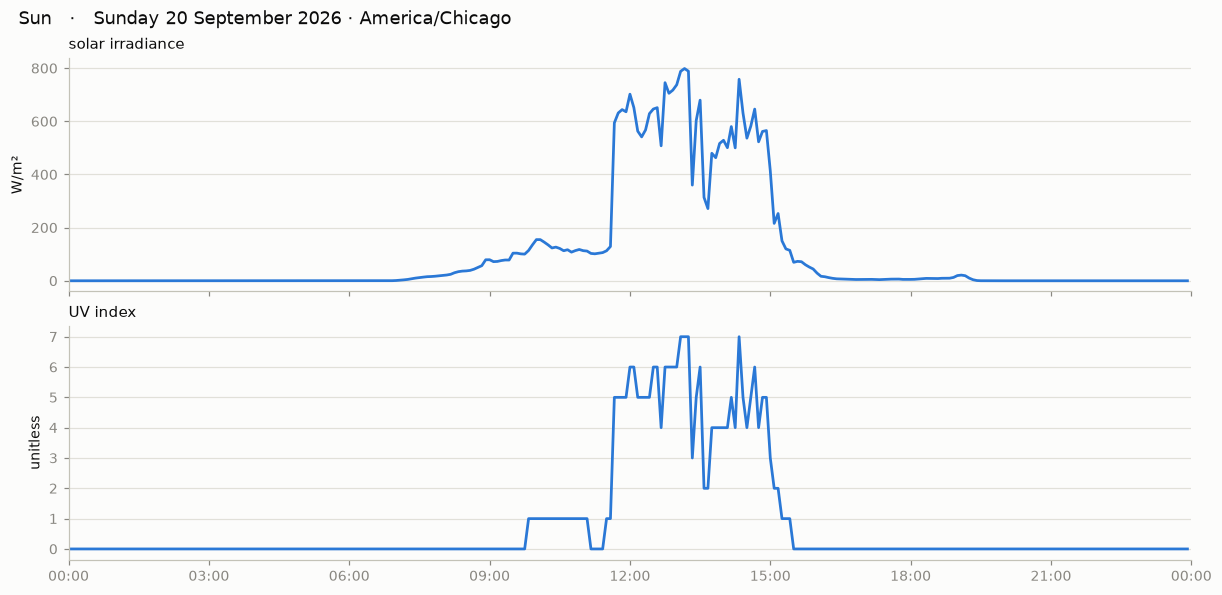

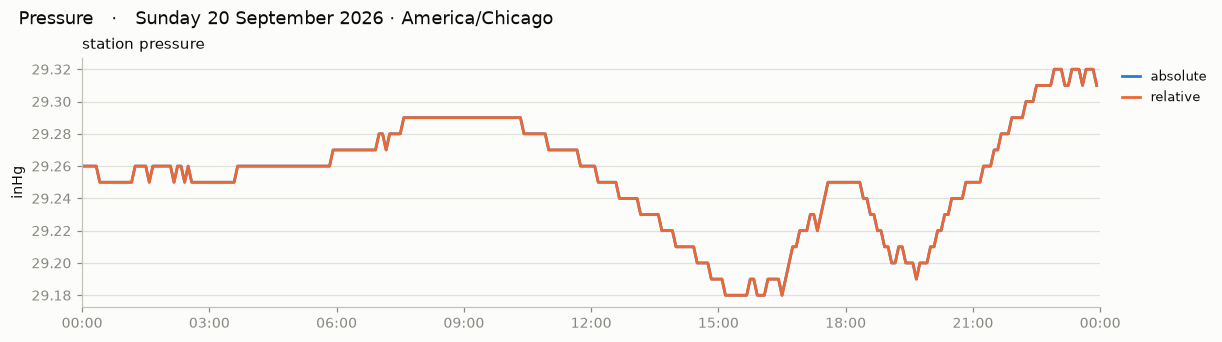

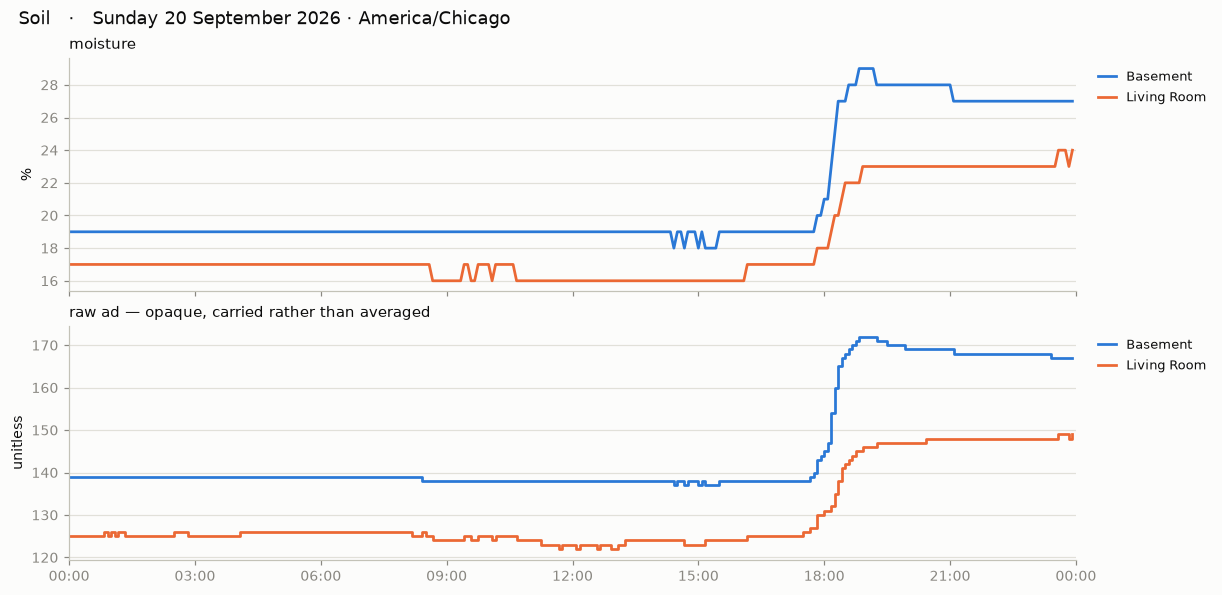

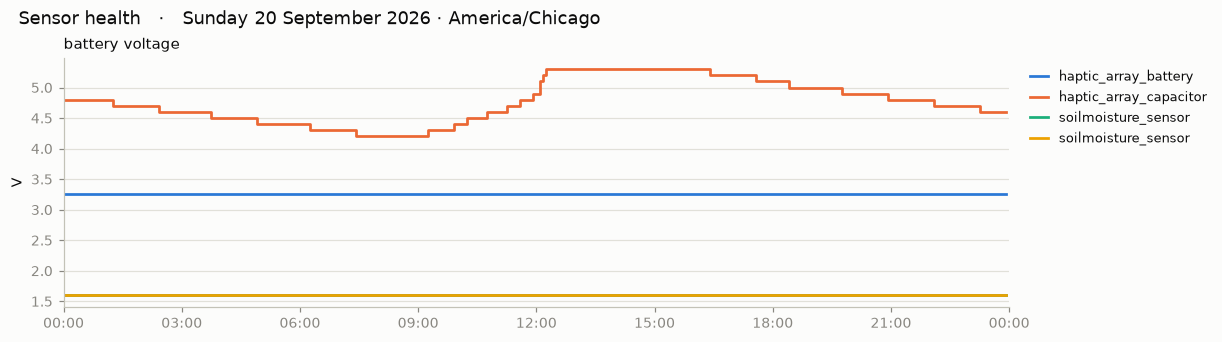

In [6]:
present = {m for m in day.columns if day[m].notna().any()}
groups = nb.logical_groups(meta, present=present)

subtitle = '   ·   ' + daily.report_title(DAY_START)
for title, panels in groups:
    if nb.plot_group(day, meta, title, panels, DAY_START, DAY_END, subtitle) is None:
        print(f'skipped {title}: nothing reported yesterday')
nb.show()

### The same detail as numbers

Three of the palette's colours sit below 3:1 contrast against the chart surface
— fine for a 2px line, but it means colour must never be the only way to read a
value. This table is that second route, and it is also the faster way to answer
"how much did it move".

`n` is five-minute slots with data, so it doubles as a per-sensor coverage
check against the slot count printed at the top.

In [7]:
detail = daily.detail_table(day, meta, groups, len(day))
print(f'{len(detail)} series · out of {len(day)} slots in the day')
print('mean omitted for accumulators (a running total has no useful average) '
      'and min/max/mean for wind direction (circular)')
display(detail.set_index(['group', 'panel', 'metric', 'where']))

41 series · out of 288 slots in the day
mean omitted for accumulators (a running total has no useful average) and min/max/mean for wind direction (circular)


unit    n     min    mean     max    last
group                     panel                           metric                 where                                                     
Temperature               every thermometer               temperature            outdoor            ºF  288   73.00   82.36  102.90   73.40
                                                                                 indoor             ºF  288   77.30   78.95   79.90   79.40
                                                                                 Basement           ºF  288   77.70   78.16   78.80   77.70
                                                                                 Living Room        ºF  288   78.40   79.10   80.10   78.80
                                                                                 Office/Bedroom     ºF  288   75.40   76.18   76.80   75.70
                          outdoor                         temperature            outdoor            ºF  288   73.00   82.36  102.90   73.40
                                                          feels_like             outdoor            ºF  288   73.00   83.42  105.80   73.40
                                                          app_temp               outdoor            ºF  288   77.50   87.75  108.10   81.00
                                                          dew_point              outdoor            ºF  288   58.10   66.09   73.10   70.00
                          indoor                          temperature            indoor             ºF  288   77.30   78.95   79.90   79.40
                                                          feels_like             indoor             ºF  288   77.30   78.95   80.00   79.40
                                                          app_tempin             indoor             ºF  288   78.50   80.37   81.60   81.10
                                                          dew_point              indoor             ºF  288   52.60   54.58   56.30   55.60
Humidity and air moisture relative humidity, every sensor humidity               outdoor             %  288   30.00   61.51   93.00   89.00
                                                                                 indoor              %  288   41.00   43.00   45.00   44.00
                                                                                 Basement            %  288   44.00   45.92   48.00   47.00
                                                                                 Living Room         %  288   41.00   43.04   45.00   45.00
                                                                                 Office/Bedroom      %  288   44.00   46.48   49.00   48.00
                          vapour pressure deficit         vpd                    outdoor          inHg  288    0.06    0.51    1.46    0.09
Wind                      speed and gust                  wind_speed             wind              mph  288    0.00    0.91    3.70    0.00
                                                          wind_gust              wind              mph  288    0.00    3.00    7.40    1.30
                          direction                       wind_direction         wind                º  288     NaN     NaN     NaN     NaN
Rain                      accumulators                    1_hour                 rainfall_piezo     in  288    0.00     NaN    0.09    0.00
                                                          daily                  rainfall_piezo     in  288    0.00     NaN    0.13    0.13
                                                          event                  rainfall_piezo     in  288    0.00     NaN    0.13    0.13
                                                          monthly                rainfall_piezo     in  288    0.25     NaN    0.38    0.38
                                                          weekly                 rainfall_piezo     in  288    0.00     NaN    0.13    0.13
                                      

## 4. Trends — 24 hours, 7 days, 30 days

Yesterday tells you what happened; this tells you whether it was unusual. One
section per realm below, each a grid: **rows are scale bands, columns are the
three periods.** All times are **America/Chicago** — stated here once rather
than on every chart.

Two rules decide what shares a chart, both there to stop a specific lie:

| Rule | Why |
|---|---|
| Split by **unit**, then by **magnitude** (>10× apart) | `outdoor` spans 69–115 ºF, 26–87 %, and 0.1–1.6 inHg. On one axis the vpd line is a flat smear on the floor — and two y-scales on one plot would be worse, because the alignment is arbitrary and invents a correlation that is not in the data. |
| **Colour follows the channel** wherever channels tell the series apart | `ch1` is the same blue in the temperature row and the humidity row, so a sensor stays recognisable across the figure. Where a band mixes different measurements, colour falls back to the metric. |

`sharey='row'` makes the three columns comparable: a flat week reads as flat
rather than being stretched to fill an axis of its own.

**Reading the 24-hour column.** Ticks sit on clock multiples (3A, 6A, 12P, 6P),
noon carries a darker rule as a fixed landmark, and the sand band is daylight —
taken from the station's own pyranometer rather than an astronomical sunrise, so
it shades the light the sensors actually saw.

The 30-day column is legitimately sparse: history starts 2026-08-01, apart from
a 65-minute burst on 07-23 that shows as an isolated stub. Gaps are drawn as
gaps, never bridged.

In [8]:
conn = nb.ensure_db()

frames = nb.fetch_periods(conn)
for period, frame in frames.items():
    filled = frame.notna().any(axis=1).sum()
    print(f'{period:>9}: {frame.shape[1]:2d} metrics x {frame.shape[0]:3d} buckets, '
          f'{filled:3d} with data ({100 * filled / len(frame):.0f}%)')

plan, colors, by_channel = nb.build_plan(frames['30 days'], meta)

# Daylight is derived from the solar series itself, so it needs no coordinates
# and reflects the light the station actually saw.
daylight = {'24 hours': nb.daylight_spans(frames['24 hours'].get('solar_and_uvi.solar'))}
spans = ', '.join(f'{a:%H:%M}-{b:%H:%M}' for a, b in daylight['24 hours']) or 'none'
print(f'\ndaylight in the last 24 h: {spans}')
print(f'{len(plan)} metrics across {plan.realm.nunique()} realms')

 24 hours: 39 metrics x  96 buckets,  93 with data (97%)
   7 days: 39 metrics x 168 buckets, 167 with data (99%)
  30 days: 39 metrics x 120 buckets, 120 with data (100%)

daylight in the last 24 h: 14:45-16:45, 17:00-17:15, 17:30-19:30, 07:15-14:00
39 metrics across 9 realms


### Outdoor

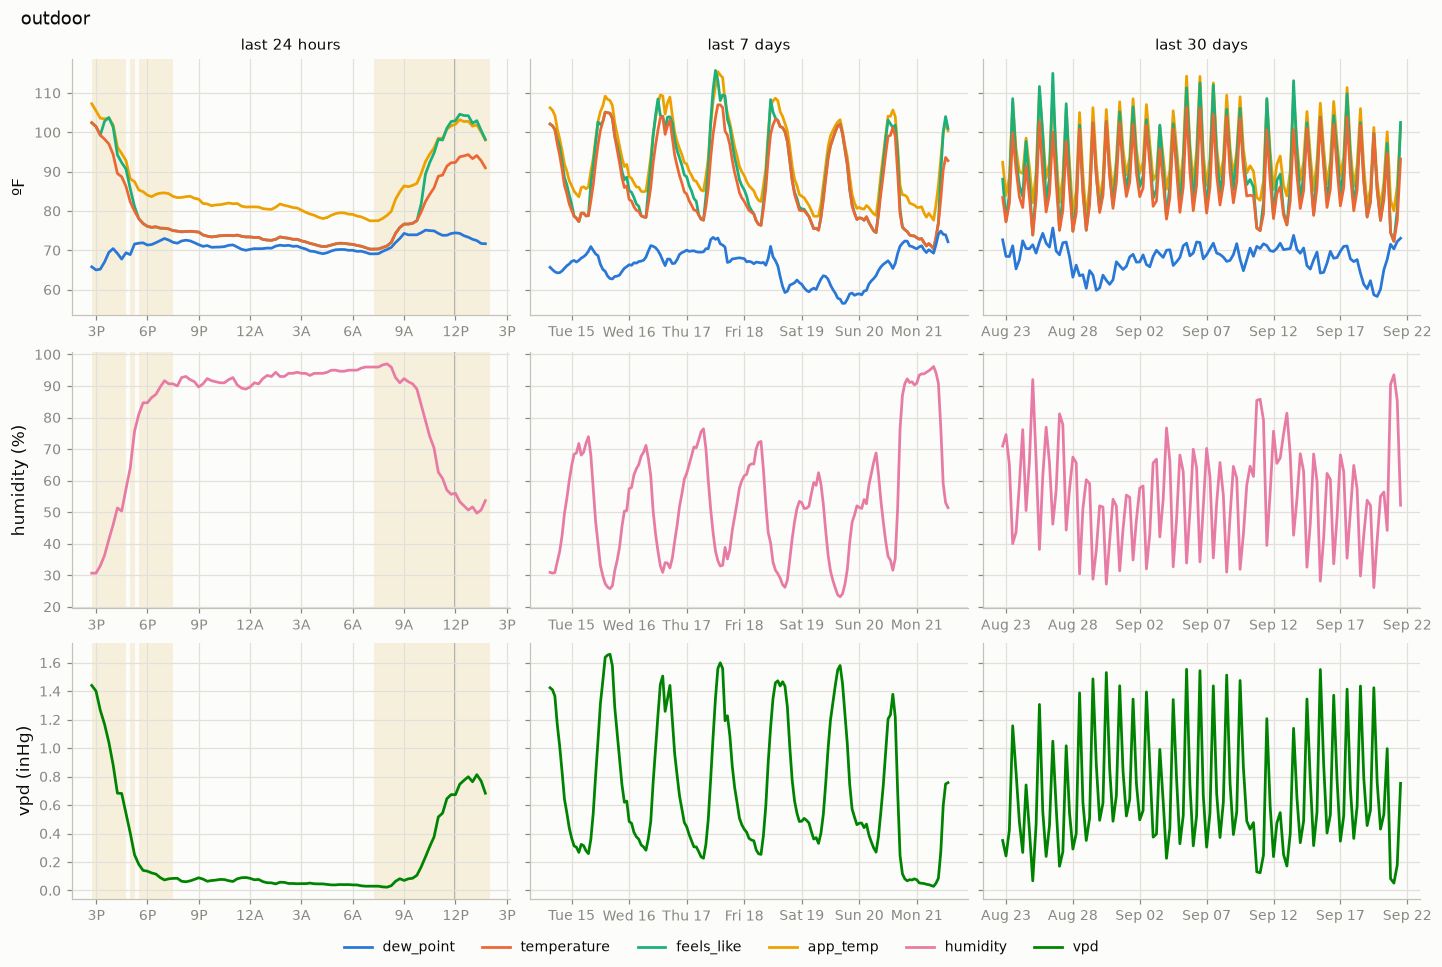

In [9]:
nb.plot_realm('outdoor', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Indoor

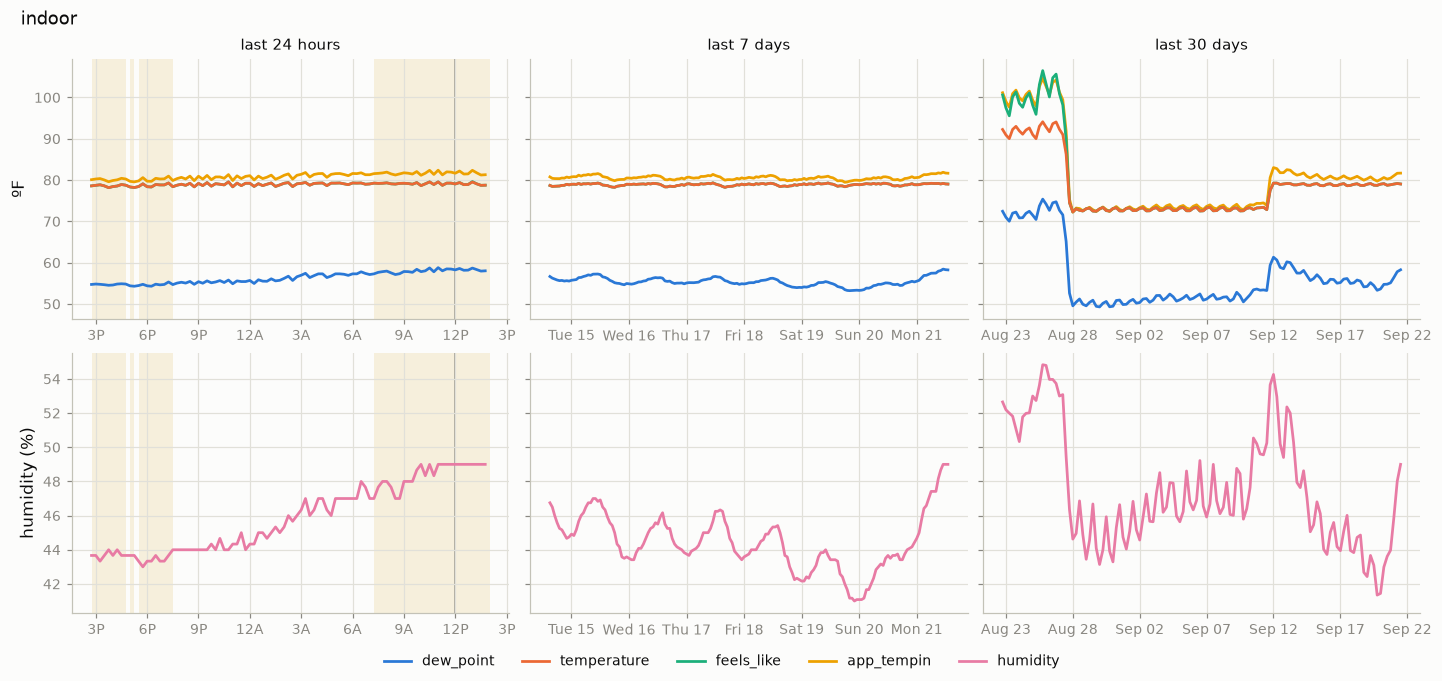

In [10]:
nb.plot_realm('indoor', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Wind

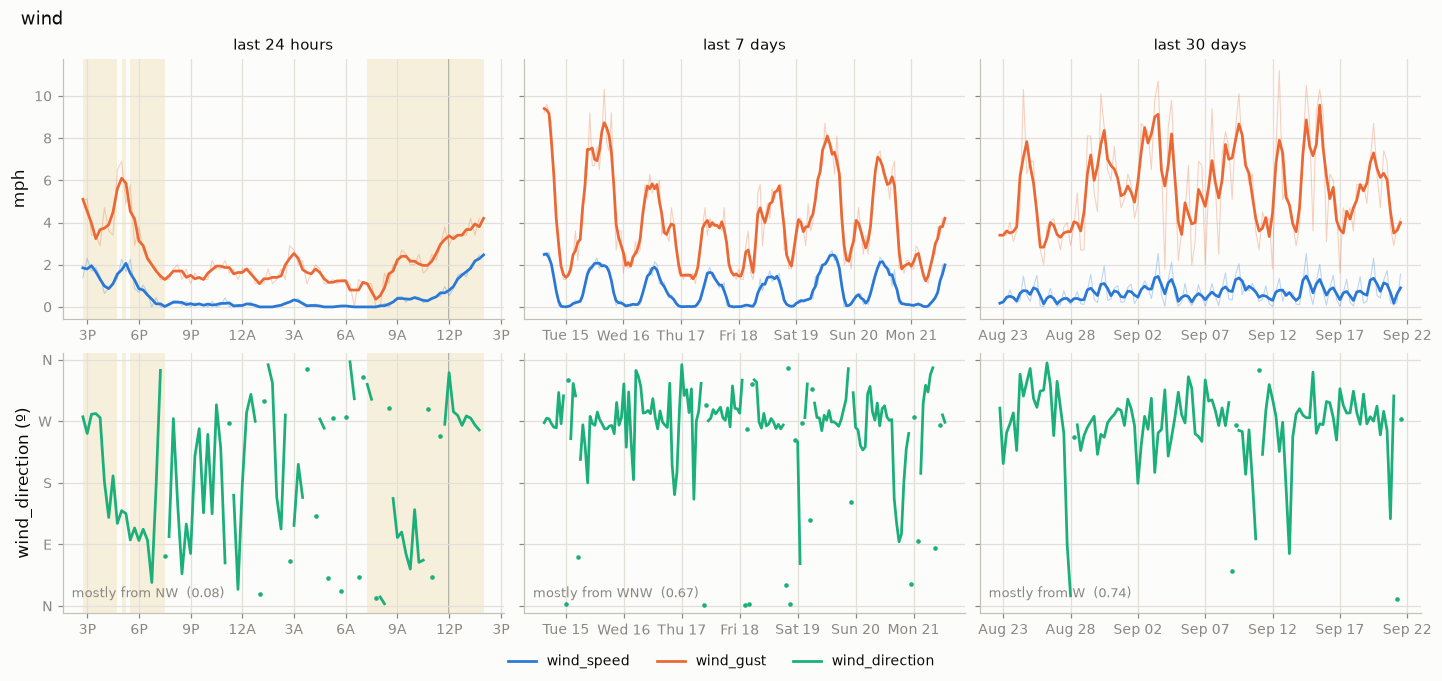

In [11]:
nb.plot_realm('wind', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

Direction is circular, so the line can only ever show it wrapping — never where
it mostly sat. The rose answers that directly: share of readings per compass
sector, with the vector-mean resultant and a steadiness score (1.0 = every
reading agreed, near 0 = the wind boxed the compass).

Speed and gust carry a **3-point moving average** as the heavy line, with the
raw trace underneath at low weight: wind is spiky enough that the raw line
hides its own shape, and nothing is smoothed away that you cannot still see.

The mean direction is a **vector** mean — `atan2` of the mean sine and cosine.
A numeric mean of 359º and 1º gives 180º: due south for a wind out of the
north.

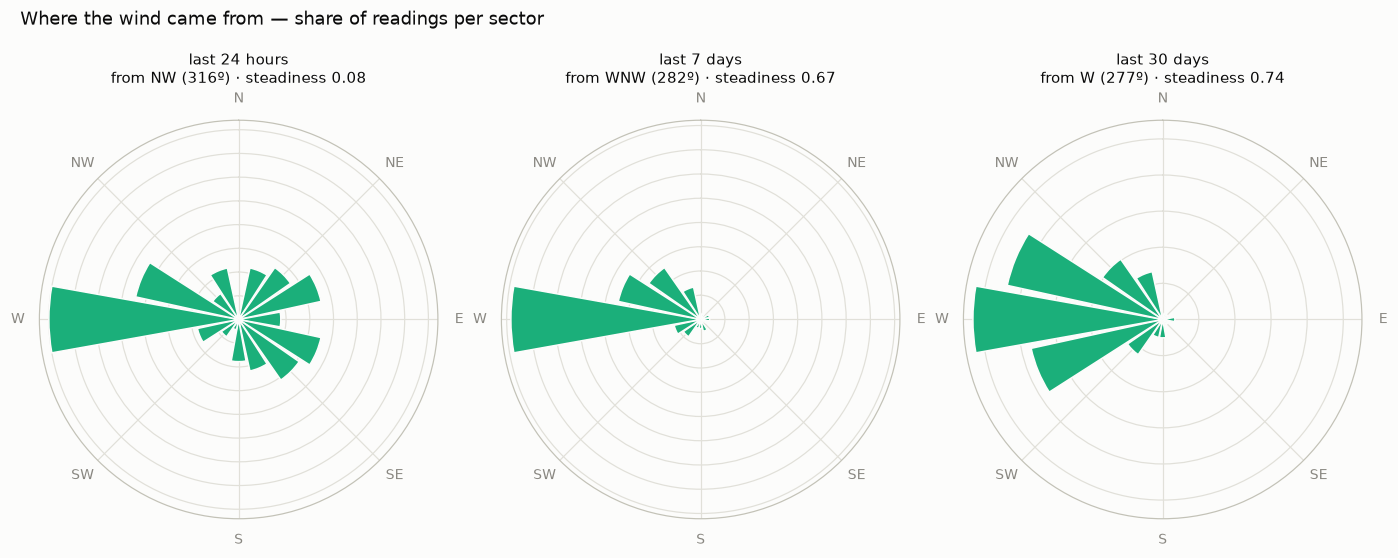

In [12]:
nb.wind_rose(frames)
nb.show()

### Sun

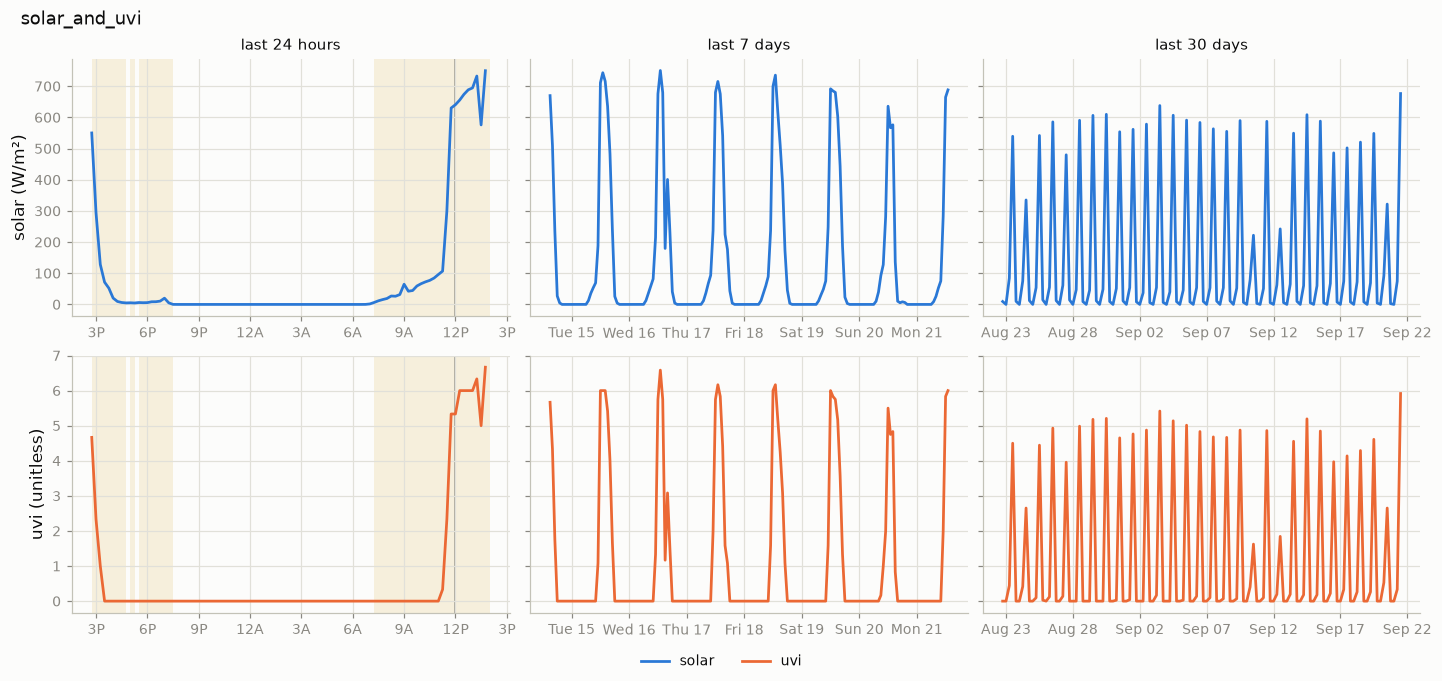

In [13]:
nb.plot_realm('solar_and_uvi', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Rain

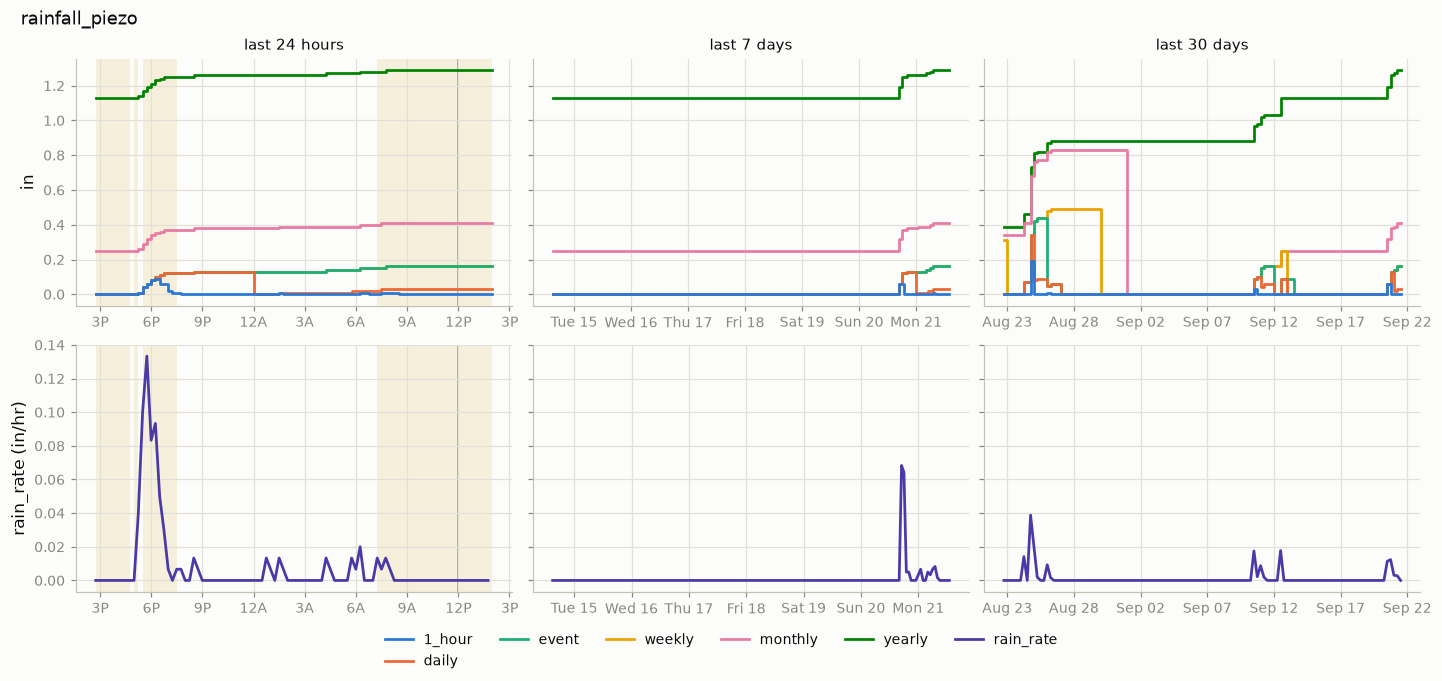

In [14]:
nb.plot_realm('rainfall_piezo', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Pressure

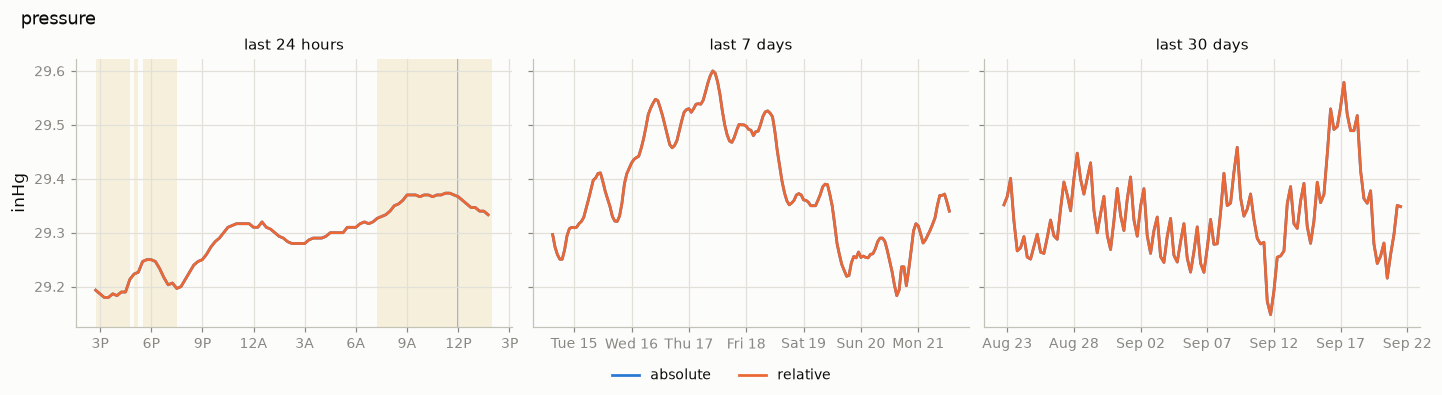

In [15]:
nb.plot_realm('pressure', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Soil

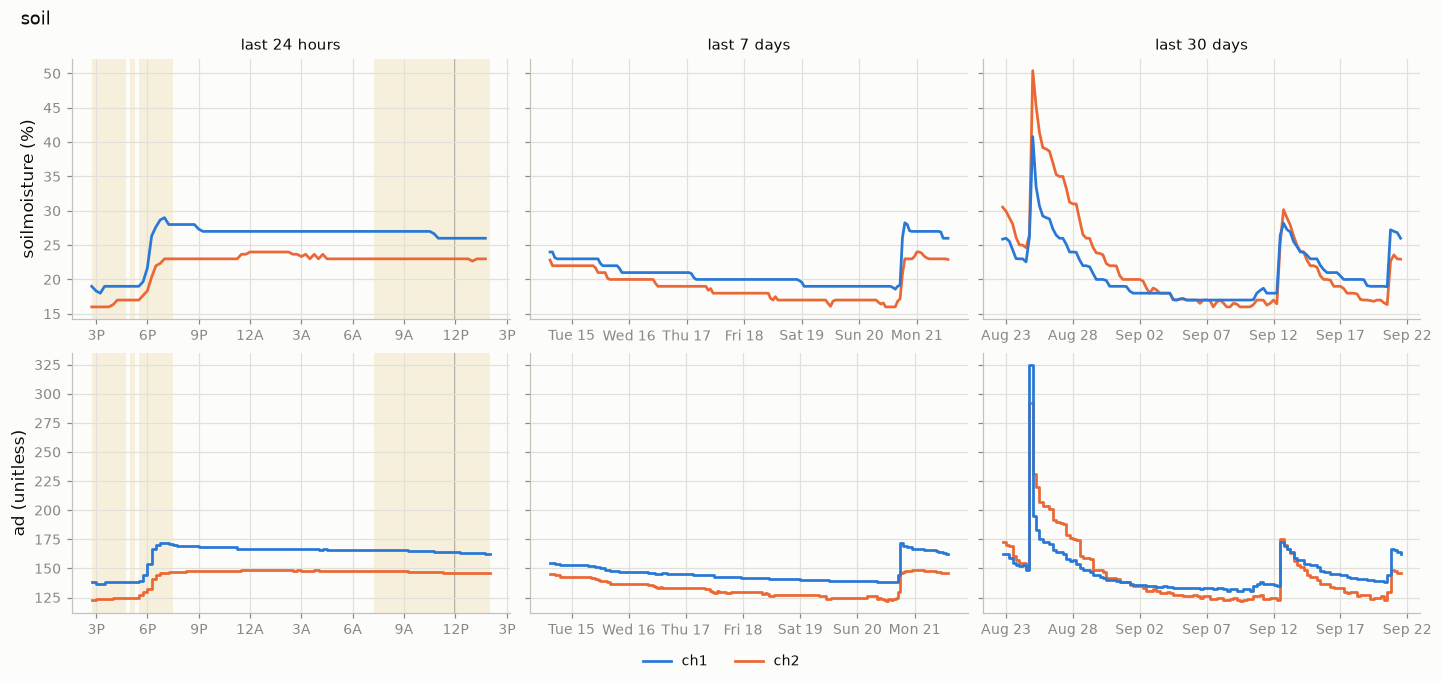

In [16]:
nb.plot_realm('soil', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Extra temp/humidity sensors

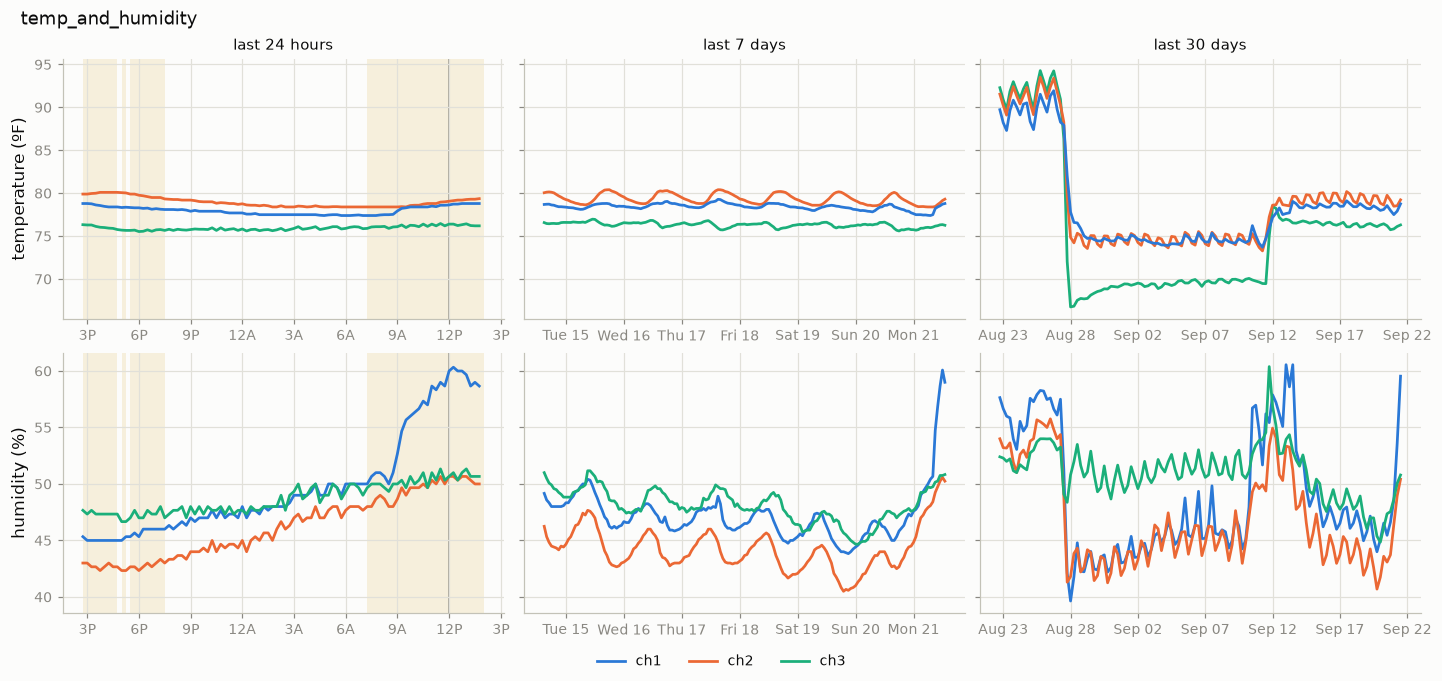

In [17]:
nb.plot_realm('temp_and_humidity', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### Sensor batteries

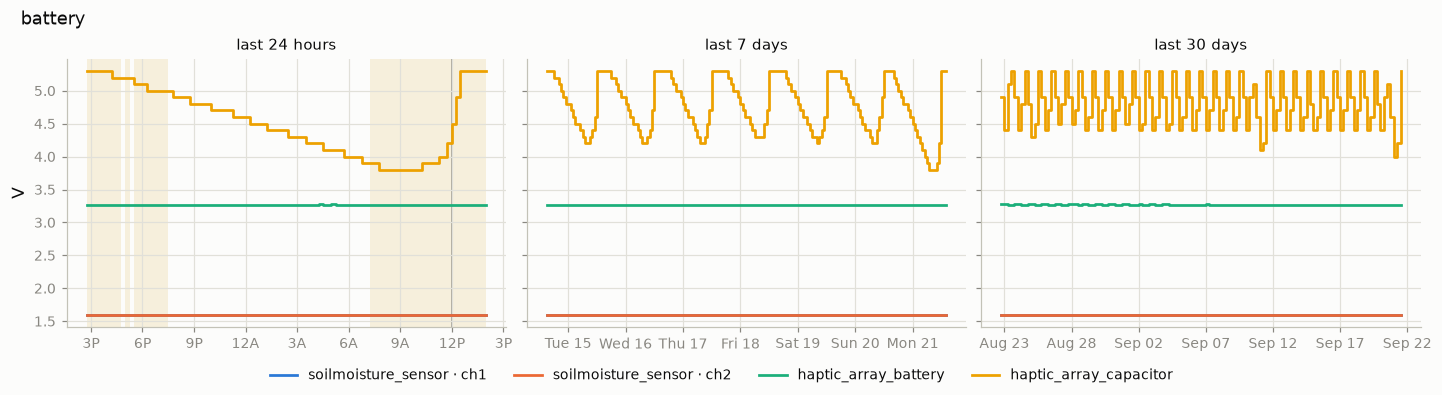

In [18]:
nb.plot_realm('battery', plan, frames, colors, by_channel, daylight=daylight)
nb.show()

### The three periods as numbers

`n` is buckets with data, so it doubles as a coverage check per period. min/max
are omitted for wind direction: 0º and 359º are one degree apart, so neither
means anything for a circular metric.

*(This table is a placeholder — it lists everything rather than saying anything.
Worth reshaping once the charts above have settled.)*

In [19]:
period_summary = nb.period_summary(plan, frames)
print(f'{len(period_summary)} metrics x {len(nb.PERIODS)} periods')
display(period_summary.set_index(['realm', 'metric', 'channel']))

39 metrics x 3 periods


unit         rule  24 hours n  24 hours min  24 hours max  7 days n  7 days min  7 days max  30 days n  30 days min  30 days max
realm             metric                 channel                                                                                                                                   
battery           soilmoisture_sensor    ch1          V         last          93          1.60          1.60       167        1.60        1.60        120         1.60         1.60
                                         ch2          V         last          93          1.60          1.60       167        1.60        1.60        120         1.60         1.60
                  haptic_array_battery                V         last          93          3.26          3.28       167        3.26        3.27        120         3.26         3.28
                  haptic_array_capacitor              V         last          93          3.80          5.30       167        3.80        5.30        120         4.00         5.30
indoor            dew_point                          ºF    recompute          93         54.30         58.80       167       53.23       58.45        120        49.29        75.39
                  temperature                        ºF         mean          93         78.17         79.57       167       78.24       79.32        120        72.29        94.12
                  feels_like                         ºF    recompute          93         78.17         79.63       167       78.24       79.35        120        72.29       106.51
                  app_tempin                         ºF    recompute          93         79.57         82.40       167       79.47       81.90        120        72.24       104.67
                  humidity                            %         mean          93         43.00         49.00       167       41.00       49.00        120        41.35        54.83
outdoor           dew_point                          ºF    recompute          93         65.00         75.13       167       56.50       74.88        120        58.25        75.67
                  temperature                        ºF         mean          93         70.30        102.43       167       70.41      106.99        120        72.29       106.36
                  feels_like                         ºF    recompute          93         70.30        104.60       167       70.41      115.73        120        72.29       115.00
                  app_temp                           ºF    recompute          93         77.50        107.27       167       77.66      115.43        120        78.44       114.29
                  humidity                            %         mean          93         30.67         97.00       167       23.17       96.17        120        26.08        93.53
                  vpd                              inHg    recompute          93          0.02          1.44       167        0.03        1.66        120         0.05         1.55
pressure          absolute                         inHg         mean          93         29.18         29.37       167       29.18       29.60        120        29.15        29.58
                  relative                         inHg         mean          93         29.18         29.37       167       29.18       29.60        120        29.15        29.58
rainfall_piezo    1_hour                             in         last          93          0.00          0.09       167        0.00        0.06        120         0.00         0.19
                  daily                              in         last          93          0.00          0.13       167        0.00        0.13        120         0.00         0.34
                  event                              in         last          93          0.00          0.16       167        0.00        0.16        120         0.00         0.44
                  weekly                             in         last          93          0

## 5. Every day since it first hit 100 ºF

Every complete local day (America/Chicago) from **the first day the station
recorded a high of 100 ºF or more** through yesterday. The start date is
computed from the data, not written down here, so it follows the record rather
than a memory of it. Days before that are commissioning and cool days, and they
say nothing about how often it gets hot.

Highs and lows are the true extremes of the **5-minute** readings, the way the
email's range chart reads them (`src/reporting/charts.py::temperature_range`) —
an hourly mean understates a peak, and this chart is about peaks.

> **The rule, stated once so the two panels cannot disagree:** a day counts as
> hot when its high **rounded to the nearest integer is 100 or more**. Both
> panels, the headline count, the percentage and the longest run all read from
> the same filtered frame, and a SQL query counts the same thing a second way —
> the `assert` in the cell fails if the two ever part company.

The left panel is every day, low to high, with hot days in the accent colour.
The right panel is the same days as a distribution of the rounded high. The two
panels do not share a y-scale: one counts degrees, the other counts days.

**This figure is meant to be shared.** It carries the station's location and a
link to its live page, both read from the environment — the repository is
public, and `02_DAILY_EMAIL_AS_BUILT` §5.2 keeps location details out of it. Set
`LAKEHOUSE_LOCATION_LABEL` and `LAKEHOUSE_STATION_URL` in `.env` to have them
drawn; without them the figure renders without them and says so. **This cell's
outputs are deliberately not committed**, because the rendered image contains
both.

In [ ]:
# Every day since the first 100 ºF day, and how often it got there (R-013).
#
# Built to be shared outside the household, so the figure names the station and
# links to it. Both come from the environment: the repo is public and
# 02_DAILY_EMAIL_AS_BUILT §5.2 keeps location out of it. Unset means the figure
# simply omits them.
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sqlalchemy import text

# The kernel's working directory is notebooks/, NOT the repo root -- so
# anchor on this module's own location rather than on cwd. Reading .env and
# writing the PNG relative to cwd silently put both in the wrong place: the
# figure rendered with no location and no link, and the image landed in
# notebooks/data/. Neither raised anything.
ROOT = Path(nb.__file__).resolve().parent.parent

try:                                    # same pattern as reporting/daily.py:185
    from dotenv import load_dotenv      # missing python-dotenv is not fatal:
    # Explicit path: find_dotenv() walks the call stack, which has no caller
    # frame under exec() and raises there.
    load_dotenv(ROOT / '.env', override=False)
except ModuleNotFoundError:             # exported variables still work
    pass

HOT = 100          # rounded daily high at or above this counts as "over 100"
LAST = '2026-09-20'                       # yesterday; today is still partial

conn = nb.ensure_db()

DAILY_SQL = """
SELECT (ts_utc AT TIME ZONE 'America/Chicago')::date AS day,
       max(value_num) AS high, min(value_num) AS low, count(*) AS slots
  FROM observation
 WHERE metric = 'outdoor.temperature' AND value_num IS NOT NULL
   AND (ts_utc AT TIME ZONE 'America/Chicago')::date <= :b
 GROUP BY 1 ORDER BY 1
"""
alld = pd.read_sql(text(DAILY_SQL), conn, params={'b': LAST})
alld['day'] = pd.to_datetime(alld['day'])
alld['high_r'] = alld.high.round().astype(int)

# The series starts at the first day that actually reached 100 -- computed, not
# hard-coded, so it follows the data. Days before it are commissioning and cool
# days that say nothing about how often it gets hot.
alld = alld[alld.slots >= 200]                    # a day, not a stub
FIRST = alld.loc[alld.high_r >= HOT, 'day'].min()
d = alld[alld.day >= FIRST].reset_index(drop=True)

over = d.high_r >= HOT
X, Y = int(over.sum()), len(d)
PCT = X / Y

# Cross-check the headline a second way: Postgres does the rounding and the
# counting, same window, no pandas in the path. A notebook cell has no pytest,
# so two methods agreeing is the test. They disagreed the first time this ran.
CHECK_SQL = """
SELECT count(*) FILTER (WHERE high_r >= :hot) AS x, count(*) AS y FROM (
  SELECT (ts_utc AT TIME ZONE 'America/Chicago')::date AS day,
         round(max(value_num))::int AS high_r
    FROM observation
   WHERE metric = 'outdoor.temperature' AND value_num IS NOT NULL
     AND (ts_utc AT TIME ZONE 'America/Chicago')::date BETWEEN :a AND :b
   GROUP BY 1) q
"""
chk = pd.read_sql(text(CHECK_SQL), conn,
                  params={'a': FIRST.date(), 'b': LAST, 'hot': HOT}).iloc[0]
assert (X, Y) == (int(chk.x), int(chk.y)), f'pandas {X}/{Y} vs SQL {chk.x}/{chk.y}'
print(f'{X} of {Y} days \u2265 {HOT} \u00baF ({PCT:.0%})  \u2014 SQL agrees: {chk.x} of {chk.y}')

streak = over.copy(); streak.index = d.day
groups = (~streak).cumsum()
runs = [(s.index.min(), s.index.max(), len(s))
        for _, s in streak[streak].groupby(groups[streak])]
run_from, run_to, run_len = max(runs, key=lambda t: t[2])
print(f'longest unbroken run: {run_len} days, {run_from:%-d %b} to {run_to:%-d %b}')


def short(ts):
    """Marc writes September as 'Sept'; every other month takes its usual %b."""
    return f"Sept {ts.day}" if ts.month == 9 else f"{ts:%b} {ts.day}"


ACCENT, MUTED = nb.SERIES_COLORS[1], nb.MUTED
nb.style()
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(15, 5.4), width_ratios=[3, 2], layout='constrained')

# ---- left: every day, low to high ------------------------------------
pos = np.arange(Y)
axL.bar(pos, d.high - d.low, bottom=d.low, width=0.68,
        color=np.where(over, ACCENT, MUTED), alpha=0.9,
        edgecolor=nb.SURFACE, linewidth=0.6, zorder=3)
axL.axhline(HOT, color=nb.INK, linewidth=1.8, alpha=0.85, zorder=4)
axL.annotate(f'{HOT} \u00baF', xy=(1.0, HOT), xycoords=('axes fraction', 'data'),
             xytext=(4, 0), textcoords='offset points', va='center',
             fontsize=9, color=nb.INK, fontweight='bold', annotation_clip=False)
# Headroom first, THEN the annotation into it: the top-right corner is only
# clear space if the y-limit puts it above every bar. Round 1 placed this by
# eye and the bounding boxes showed it sitting on a bar.
axL.set_ylim(d.low.min() - 3, d.high.max() + 11)
axL.annotate(f'{X} of {Y} days \u2265 {HOT} \u00baF ({PCT:.0%})',
             xy=(0.985, 0.955), xycoords='axes fraction', ha='right', va='top',
             fontsize=13, fontweight='bold', color=nb.INK)
ticks = list(range(0, Y, 7))
axL.set_xticks(ticks)
axL.set_xticklabels([short(d.day.iloc[i]) for i in ticks], fontsize=9)
axL.set_ylabel('\u00baF')
axL.set_xlim(-0.9, Y - 0.1)
axL.set_title(f'Daily low to high \u2014 {short(d.day.iloc[0])} to '
              f'{short(d.day.iloc[-1])}, {d.day.iloc[-1].year}',
              loc='left', fontsize=11, color=nb.INK)

# ---- right: how hot, as a distribution -------------------------------
counts = d.high_r.value_counts().sort_index()
bins = np.arange(counts.index.min(), counts.index.max() + 1)
vals = np.array([counts.get(b, 0) for b in bins])
axR.bar(bins, vals, width=0.82, color=np.where(bins >= HOT, ACCENT, MUTED),
        alpha=0.9, edgecolor=nb.SURFACE, linewidth=0.6, zorder=3)
for b, v in zip(bins, vals):
    if v:                               # skip empty bins
        axR.annotate(f'{v}', xy=(b, v), xytext=(0, 5),
                     textcoords='offset points', ha='center', va='bottom',
                     fontsize=9, color=nb.INK)
axR.set_xlabel('Daily high (\u00baF, rounded)')
axR.set_ylabel('days')
axR.set_xticks([t for t in bins if t % 5 == 0])
axR.yaxis.set_major_locator(MultipleLocator(5))     # integers only, every 5
axR.set_ylim(0, vals.max() * 1.22)
axR.set_xlim(bins.min() - 1, bins.max() + 1)
axR.set_title(f'High Temp Distribution {short(d.day.iloc[0])} to '
              f'{short(d.day.iloc[-1])}, {d.day.iloc[-1].year} ({Y} days)',
              loc='left', fontsize=11, color=nb.INK)

for ax in (axL, axR):
    ax.grid(axis='y', color=nb.GRID, linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

# ---- for sharing: where it is, and where to see it live ---------------
place = os.environ.get('LAKEHOUSE_LOCATION_LABEL', '').strip()
url = os.environ.get('LAKEHOUSE_STATION_URL', '').strip()
if place:
    fig.suptitle(f'Lake house weather station \u2014 {place}',
                 x=0.005, ha='left', fontsize=14, fontweight='bold', color=nb.INK)
if url:
    shown = url.split('://', 1)[-1].removeprefix('www.')
    fig.supxlabel(f'Live station: {shown}', x=0.005, ha='left',
                  fontsize=9, color=nb.MUTED)

out = ROOT / 'data/reports/preview/hot-days.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=220, facecolor=nb.SURFACE)     # full res, for sharing
print(f'wrote {out} at 220 dpi'
      f'{"" if place else "  (no LAKEHOUSE_LOCATION_LABEL — drawn without it)"}'
      f'{"" if url else "  (no LAKEHOUSE_STATION_URL — drawn without it)"}')
plt.show()


In [21]:
nb.shutdown()

connection closed
